# Task 4: Channel effectiveness, measured
**Important:** the human trials (parts 2 and 3) need a real person and I cannot be one. This notebook builds the stimuli and a runner page, and analyses the results *when you supply them*. `reader_estimate` is never filled in by code here.

**Workflow**
1. Run the cells down to the stimulus builder. It writes `run_experiment.html` (self-contained, 30 shuffled trials) and `stimuli/`.
2. Open `run_experiment.html` in a browser and have a reader do all 30. Click *Download CSV* and save it as `channel_results.csv` next to this notebook.
3. Re-run from the results cell: it recomputes `absolute_error = abs(reader_estimate/100 - true_ratio)`, plots the ranking and compares it with the published one.

Every chart uses the object-oriented API.

In [1]:
import os, io, json, base64, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Rectangle

trials = pd.read_csv('channel_trials.csv', dtype=str)          # keep strings so the exported CSV matches the original formatting
t = trials.astype({'true_ratio': float, 'value_large': float, 'value_small': float})
assert len(t) == 30 and t.channel.nunique() == 5 and (t.groupby('channel').true_ratio.nunique() == 6).all()
assert np.allclose(t.value_small / t.value_large, t.true_ratio)
assert trials.reader_estimate.isna().all()                      # blank until a real reader fills it
GREY, HI = '#9a9a9a', '#cc3311'

## 1. Five channels, one function each
No axes, tick values or numbers appear on any stimulus. Each pair is drawn on the same 0 to 100 canvas, so the large value varies from trial to trial (45 to 88) and the reader cannot learn a fixed "large" size.

| Channel | Encoding | Attribute | Suited to ratio data? |
|---|---|---|---|
| position | two dots on one common vertical scale, unlabeled caps at zero and full scale | position on a common scale | yes, best |
| length | two bars from a common zero baseline | length | yes |
| angle | two adjacent wedges of one pie, 2.2° per unit | angle | moderately |
| area | two circles, **`s = 78 × value`** | area | weakly |
| colour | two squares, grey ink proportional to value, sequential ramp | lightness | no zero point; poor for ratios |

**Area, as warned:** in `ax.scatter`, `s` is area, so I set `s` proportional to the value. I did **not** square it, so the classic area lie was avoided. For colour I used a sequential grey ramp (white = 0, black = 100), never a rainbow.

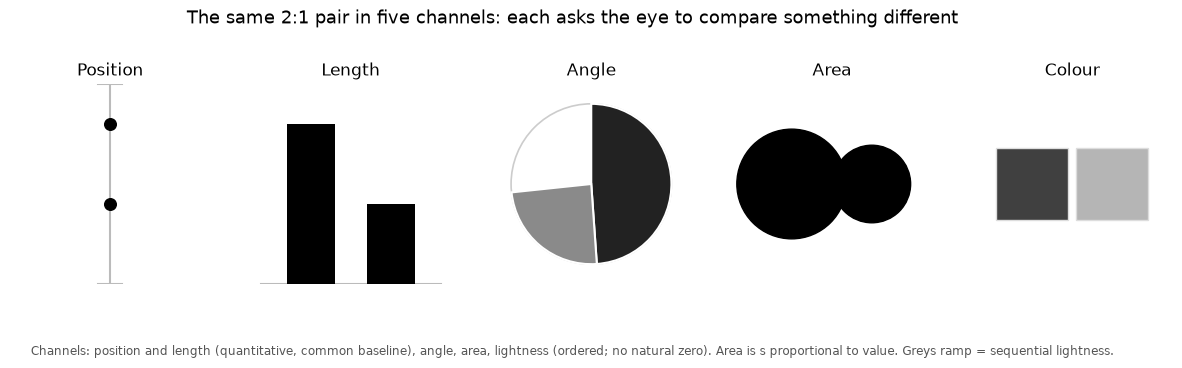

In [2]:
# Five tiny chart functions. Each draws ONE pair (big, small) on a 0-100 canvas with one channel.
# No axis labels, tick values or numbers: the reader decodes from the channel alone.
K_AREA, K_ANGLE = 78, 2.2     # scatter s = 78*value  (s is AREA in points^2, so area is proportional to value)
                              # wedge angle = 2.2 degrees per unit of value (max pair sum 151.7 -> 334 deg, fits one pie)
def new_axes():
    fig, ax = plt.subplots(figsize=(3.2, 3.2), dpi=100)
    ax.set_position([0, 0, 1, 1]); ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect('equal'); ax.axis('off')
    return fig, ax

def pos_xy(big, small, left):                       # which value goes on which side (randomised per trial)
    return ((30, 70), (big, small)) if left else ((30, 70), (small, big))

def draw_position(ax, big, small, left):            # two dots on ONE common scale; unlabeled caps mark zero and full scale
    ax.plot([50, 50], [0, 100], color='#bbbbbb', lw=1.5)
    for y in (0, 100): ax.plot([44, 56], [y, y], color='#bbbbbb', lw=1.5)
    ax.scatter([50, 50], [big, small], s=70, color='black', zorder=3)

def draw_length(ax, big, small, left):              # two bars from a common zero baseline
    xs, vs = pos_xy(big, small, left)
    ax.plot([5, 95], [0, 0], color='#bbbbbb', lw=1.5)
    ax.bar(xs, vs, width=24, color='black', zorder=2)

def draw_angle(ax, big, small, left):               # two adjacent wedges of one pie, angle proportional to value
    first, second = (big, small) if left else (small, big)
    a1, a2 = first * K_ANGLE, second * K_ANGLE
    ax.add_patch(plt.Circle((50, 50), 40, fill=False, edgecolor='#cccccc', lw=1.2))
    ax.add_patch(Wedge((50, 50), 40, 90 - a1, 90, facecolor='#222222', edgecolor='white', lw=1.5))
    ax.add_patch(Wedge((50, 50), 40, 90 - a1 - a2, 90 - a1, facecolor='#8a8a8a', edgecolor='white', lw=1.5))

def draw_area(ax, big, small, left):                # two circles; s is AREA, so s = K * value (NOT value**2)
    xs, vs = pos_xy(big, small, left)
    ax.scatter(xs, [50, 50], s=K_AREA * np.array(vs), color='black')

def draw_colour(ax, big, small, left):              # two squares; grey ink proportional to value (white=0, black=100)
    xs, vs = pos_xy(big, small, left)
    for x, v in zip(xs, vs):
        ax.add_patch(Rectangle((x - 18, 32), 36, 36, facecolor=plt.cm.Greys(v / 100), edgecolor='#dddddd', lw=1))

DRAW = dict(position=draw_position, length=draw_length, angle=draw_angle, area=draw_area, colour=draw_colour)

# Documentation figure: ONE example pair (not one of the 30 trial pairs), five channels
fig, axs = plt.subplots(1, 5, figsize=(15, 3.6))
for ax, (name, f) in zip(axs, DRAW.items()):
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.set_aspect('equal'); ax.axis('off')
    f(ax, 80, 40, True); ax.set_title(name.capitalize(), fontsize=12)
fig.suptitle('The same 2:1 pair in five channels: each asks the eye to compare something different', fontsize=13)
fig.text(0.5, 0.02, 'Channels: position and length (quantitative, common baseline), angle, area, lightness (ordered; no natural zero). '
         'Area is s proportional to value. Greys ramp = sequential lightness.', ha='center', fontsize=8.5, color='#555')
fig.savefig('t4_five_channels_example.png', dpi=130, bbox_inches='tight'); plt.show()

## 2. Build the 30 stimuli and the runner
Left/right placement of the large item is randomised per trial (`stimuli_manifest.csv`). The runner page shuffles the 30 trials at load, shows no feedback, and reveals only mean errors at the end.

In [3]:
rng = np.random.default_rng(4)
os.makedirs('stimuli', exist_ok=True)
manifest, payload = [], []
for (_, r), row in zip(t.iterrows(), trials.to_dict('records')):
    left = bool(rng.integers(0, 2))                  # large item on the left? (randomised)
    fig, ax = new_axes()
    DRAW[r.channel](ax, r.value_large, r.value_small, left)
    buf = io.BytesIO(); fig.savefig(buf, format='png', dpi=100); plt.close(fig)
    open(f'stimuli/trial_{int(r.trial):02d}.png', 'wb').write(buf.getvalue())
    manifest.append(dict(trial=int(r.trial), channel=r.channel, large_on_left=left))
    payload.append({k: row[k] for k in ('trial', 'channel', 'true_ratio', 'value_large', 'value_small')}
                   | {'img': base64.b64encode(buf.getvalue()).decode()})
pd.DataFrame(manifest).to_csv('stimuli_manifest.csv', index=False)

HTML = r"""<!doctype html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1"><title>Channel trials</title>
<style>body{font:16px system-ui,sans-serif;max-width:560px;margin:2rem auto;padding:0 1rem;background:#fff;color:#222}img{width:320px;height:320px;display:block;margin:1rem 0;border:1px solid #ddd}input{width:6rem;font-size:1.1rem;padding:.3rem}button{font-size:1rem;padding:.4rem 1rem;margin:.3rem .3rem .3rem 0}.p{color:#777}.e{color:#b00}textarea{width:100%;height:9rem;font:12px monospace}td,th{padding:.2rem .8rem;text-align:left}</style></head>
<body><main id="m"></main><script>
const T=__TRIALS__;
const order=T.map((_,i)=>i);
for(let i=order.length-1;i>0;i--){const j=Math.floor(Math.random()*(i+1));[order[i],order[j]]=[order[j],order[i]];}
const est={};let k=0;const m=document.getElementById('m');
function intro(){m.innerHTML='<h1>Estimating ratios</h1><p>You will see '+T.length+' images, one at a time, each showing two values. For each one, estimate: <b>the smaller one is what percentage of the larger one?</b></p><p>Type a number from 0 to 100. Judge by eye only (no ruler, no zooming, no measuring). A guess is fine. Answers are revealed only at the end.</p><button onclick="show()">Start</button>';}
function show(){
 if(k>=order.length)return done();
 const t=T[order[k]];
 m.innerHTML='<p class="p">Image '+(k+1)+' of '+T.length+'</p><img alt="" src="data:image/png;base64,'+t.img+'"><p>The smaller one is what percentage of the larger one?</p><input id="a" type="number" min="0" max="100" step="any"> % <button onclick="save()">Next</button><p id="e" class="e"></p>';
 const a=document.getElementById('a');a.focus();a.addEventListener('keydown',e=>{if(e.key==='Enter')save();});
}
function save(){
 const v=parseFloat(document.getElementById('a').value);
 if(!(v>=0&&v<=100)){document.getElementById('e').textContent='Please enter a number between 0 and 100.';return;}
 est[T[order[k]].trial]=v;k++;show();
}
function done(){
 const err=t=>Math.abs(est[t.trial]/100-parseFloat(t.true_ratio));
 const rows=T.map(t=>[t.trial,t.channel,t.true_ratio,t.value_large,t.value_small,est[t.trial],+err(t).toFixed(4)].join(','));
 const csv='trial,channel,true_ratio,value_large,value_small,reader_estimate,absolute_error\n'+rows.join('\n')+'\n';
 const g={};T.forEach(t=>{(g[t.channel]=g[t.channel]||[]).push(err(t));});
 const s=Object.entries(g).map(([c,a])=>[c,a.reduce((x,y)=>x+y,0)/a.length]).sort((p,q)=>p[1]-q[1]);
 m.innerHTML='<h1>Done</h1><p>Mean absolute error by channel (lower is better):</p><table>'+s.map(([c,x])=>'<tr><td>'+c+'</td><td>'+(x*100).toFixed(1)+' points</td></tr>').join('')+'</table><p>Save the results as <b>channel_results.csv</b> next to the notebook:</p><button id="d">Download CSV</button><button id="c">Copy CSV</button><p>If the buttons do nothing, copy the text below into a file with that name.</p><textarea id="t" readonly></textarea>';
 document.getElementById('t').value=csv;
 document.getElementById('d').onclick=()=>{const a=document.createElement('a');a.href=URL.createObjectURL(new Blob([csv],{type:'text/csv'}));a.download='channel_results.csv';a.click();};
 document.getElementById('c').onclick=()=>navigator.clipboard&&navigator.clipboard.writeText(csv);
}
intro();
</script></body></html>"""
open('run_experiment.html', 'w').write(HTML.replace('__TRIALS__', json.dumps(payload)))
print('wrote run_experiment.html', round(os.path.getsize('run_experiment.html') / 1024), 'KB and', len(payload), 'stimuli in ./stimuli/')

wrote run_experiment.html 157 KB and 30 stimuli in ./stimuli/


## 3. Results (needs your completed `channel_results.csv`)
Ranking plot: one bar per channel, sorted, zero baseline, whiskers = ±1 standard error. Compared with the published ranking **position > length > angle > area > volume > colour**; volume was not tested here, so the comparison uses the five tested channels in published order.

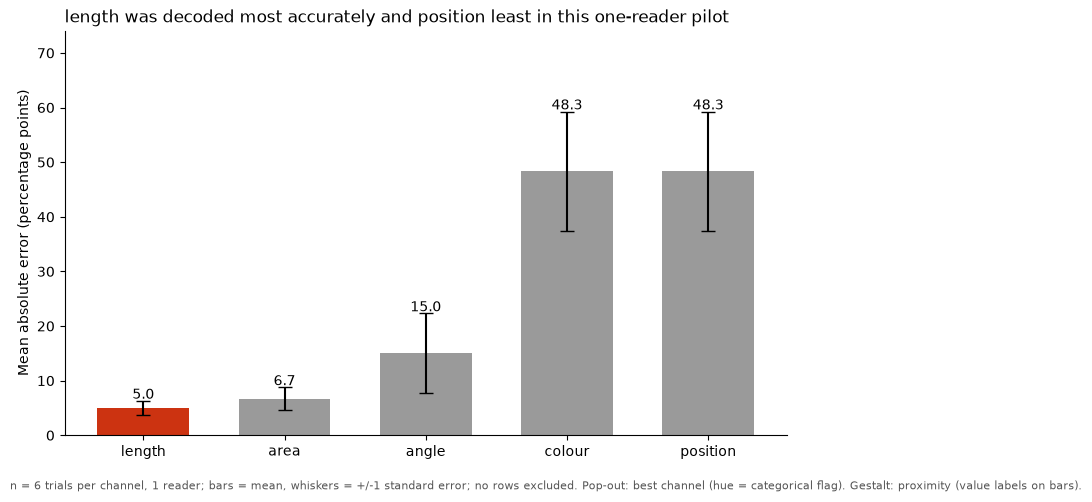

          published_rank  my_rank  rank_shift agrees
position               1        5           4     no
length                 2        1          -1     no
angle                  3        3           0    yes
area                   4        2          -2     no
colour                 5        4          -1     no

5 of 10 channel pairs are ordered as published.
Pairs ordered AGAINST the published ranking: [('position', 'length'), ('position', 'angle'), ('position', 'area'), ('position', 'colour'), ('angle', 'area')]
Pairs whose means differ by less than their combined standard error (not distinguishable here): [('position', 'colour'), ('length', 'area')]


In [4]:
RES = 'channel_results.csv'
HAVE = False
if os.path.exists(RES):
    res = pd.read_csv(RES)
    HAVE = len(res) == 30 and res.reader_estimate.notna().all()
if not HAVE:
    print('No completed channel_results.csv found: nothing is invented here.\n'
          'Open run_experiment.html, run all 30 trials with a real reader, save the CSV next to this notebook, then re-run from this cell.')
else:
    res['absolute_error'] = (res.reader_estimate / 100 - res.true_ratio).abs()      # as specified
    res.to_csv(RES, index=False)
    st = (res.groupby('channel').absolute_error.agg(mean='mean', sem='sem', n='count') * [100, 100, 1]).sort_values('mean')
    best, worst = st.index[0], st.index[-1]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(st.index, st['mean'], yerr=st['sem'], capsize=5, color=[HI if c == best else GREY for c in st.index], width=0.65)
    for i, c in enumerate(st.index): ax.text(i, st.loc[c, 'mean'] + st.loc[c, 'sem'] + 0.4, f"{st.loc[c, 'mean']:.1f}", ha='center')
    ax.set_ylim(0, (st['mean'] + st['sem']).max() * 1.25); ax.set_ylabel('Mean absolute error (percentage points)')
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    ax.set_title(f"{best} was decoded most accurately and {worst} least in this one-reader pilot", fontsize=12, loc='left')
    fig.text(0.01, 0.01, 'n = 6 trials per channel, 1 reader; bars = mean, whiskers = +/-1 standard error; no rows excluded. '
             'Pop-out: best channel (hue = categorical flag). Gestalt: proximity (value labels on bars).', fontsize=8, color='#555')
    fig.tight_layout(rect=[0, 0.04, 1, 1]); fig.savefig('t4_channel_ranking.png', dpi=130); plt.show()

    PUB = ['position', 'length', 'angle', 'area', 'colour']          # published order, volume dropped (not tested here)
    cmp_ = pd.DataFrame({'published_rank': range(1, 6)}, index=PUB)
    cmp_['my_rank'] = [list(st.index).index(c) + 1 for c in PUB]
    cmp_['rank_shift'] = cmp_.my_rank - cmp_.published_rank
    cmp_['agrees'] = np.where(cmp_.rank_shift == 0, 'yes', 'no')
    print(cmp_)
    pairs = [(a, b) for i, a in enumerate(PUB) for b in PUB[i + 1:]]
    ok = [(a, b) for a, b in pairs if st.loc[a, 'mean'] < st.loc[b, 'mean']]
    print(f"\n{len(ok)} of {len(pairs)} channel pairs are ordered as published.")
    print('Pairs ordered AGAINST the published ranking:', [p for p in pairs if p not in ok] or 'none')
    close = [(a, b) for a, b in pairs if abs(st.loc[a, 'mean'] - st.loc[b, 'mean']) < np.hypot(st.loc[a, 'sem'], st.loc[b, 'sem'])]
    print('Pairs whose means differ by less than their combined standard error (not distinguishable here):', close or 'none')

**Reading your result.** The cell above prints, from your data, which channels agree with the published rank, which pairs are reversed, and which pairs are too close to separate. Write your own agree/disagree sentences from that output; I have deliberately not pre-written them, because no estimates have been collected.

## 4. Apply it: iris petal length, same message, two channels
Message: setosa petals are far shorter than the other species. **High-ranking channel:** position. **Low-ranking channel:** colour lightness. Both charts carry the same numberless title and the same 150 flowers.

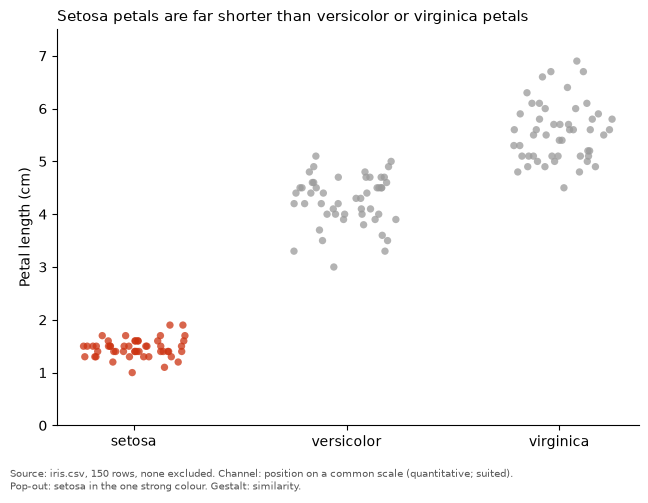

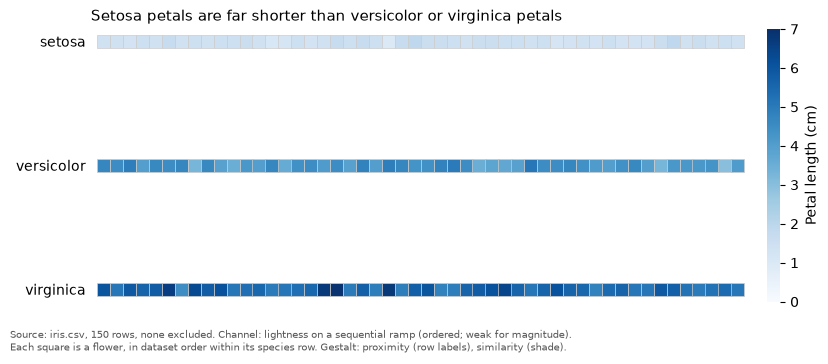

{'setosa': 1.5, 'versicolor': 4.35, 'virginica': 5.55} | ratio of setosa median to the others: {'versicolor': 0.34, 'virginica': 0.27}


In [5]:
iris = pd.read_csv('iris.csv') if os.path.exists('iris.csv') else \
       pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')
spp = ['setosa', 'versicolor', 'virginica']
med = iris.groupby('species').petal_length.median()
TITLE = 'Setosa petals are far shorter than versicolor or virginica petals'   # same message, no numbers, on both charts
rg = np.random.default_rng(1)

# Chart A: HIGH-ranking channel = position on a common scale
fig, ax = plt.subplots(figsize=(6.5, 5))
for i, sp in enumerate(spp):
    d = iris[iris.species == sp]
    ax.scatter(i + rg.uniform(-0.25, 0.25, len(d)), d.petal_length, s=28, alpha=0.75, edgecolor='none',
               color=HI if sp == 'setosa' else GREY)               # s is a constant here: petal_length is NOT encoded by size
ax.set_xticks(range(3)); ax.set_xticklabels(spp); ax.set_ylim(0, 7.5); ax.set_ylabel('Petal length (cm)')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
ax.set_title(TITLE, fontsize=11, loc='left')
fig.text(0.01, 0.01, 'Source: iris.csv, 150 rows, none excluded. Channel: position on a common scale (quantitative; suited).\n'
         'Pop-out: setosa in the one strong colour. Gestalt: similarity.', fontsize=7.5, color='#555')
fig.tight_layout(rect=[0, 0.06, 1, 1]); fig.savefig('t4_iris_position.png', dpi=130); plt.show()

# Chart B: LOW-ranking channel = colour lightness (sequential Blues ramp, not a rainbow)
fig, ax = plt.subplots(figsize=(9, 3.6))
for i, sp in enumerate(spp):
    d = iris[iris.species == sp].reset_index(drop=True)
    sc = ax.scatter(range(len(d)), [i] * len(d), c=d.petal_length, cmap='Blues', vmin=0, vmax=7, marker='s', s=90,
                    edgecolor='#cccccc', linewidth=0.5)
ax.set_yticks(range(3)); ax.set_yticklabels(spp); ax.set_xticks([]); ax.invert_yaxis(); ax.set_xlim(-1, 50)
for s in ax.spines.values(): s.set_visible(False)
ax.tick_params(axis='y', length=0)
cb = fig.colorbar(sc, ax=ax, ticks=range(0, 8), pad=0.02); cb.set_label('Petal length (cm)'); cb.outline.set_visible(False)
ax.set_title(TITLE, fontsize=11, loc='left')
fig.text(0.01, 0.01, 'Source: iris.csv, 150 rows, none excluded. Channel: lightness on a sequential ramp (ordered; weak for magnitude).\n'
         'Each square is a flower, in dataset order within its species row. Gestalt: proximity (row labels), similarity (shade).', fontsize=7.5, color='#555')
fig.tight_layout(rect=[0, 0.08, 1, 1]); fig.savefig('t4_iris_colour.png', dpi=130); plt.show()
print(med.round(2).to_dict(), '| ratio of setosa median to the others:', (med['setosa'] / med[['versicolor', 'virginica']]).round(2).to_dict())

**Which I would publish: the position chart.** The message is "far shorter", which is a magnitude claim (setosa's median is roughly a third of the others'). With position, that ratio is read directly from distance along a common scale that starts at zero. With colour, the reader can see that the setosa row is paler, but a pale-versus-dark contrast cannot be turned into "about a third": lightness has no natural zero, is perceived non-linearly, and has to be decoded through the colour bar, which means holding a shade in working memory and matching it. The criterion is decoding accuracy, not looks. The colour version is the better *looking* one, which is exactly why it should not win.

## The question: what 30 data points can and cannot support
**Can support**
- A working pipeline: stimuli, runner, scoring and ranking all run end to end.
- A rough picture of *this one reader's* errors on *these* 30 pairs, and a gut-check on whether any difference between channels is large relative to its noise (compare the whiskers).
- A demonstration, to the reader, that judging by eye is harder than it feels.

**Cannot support**
- **Any claim about readers in general.** One reader is n = 1; their habits (rounding to 25/50/75, anchoring on 50%) are in every channel.
- **A rank order.** Each channel has 6 trials, so each mean has a wide standard error; adjacent channels will usually overlap. The code prints which pairs are indistinguishable.
- **Clean channel comparisons.** Channel is confounded with the particular values and stimulus design: the angle task shows two wedges in one pie, and "what percentage of the lighter square" has no true zero. The reader also probably knows the hypothesis.
- **Volume**, which was not tested.
- **Statistical significance.** No test here has power; do not report p-values.

**Why the published ranking is still worth following even if your sample disagrees.** It comes from many readers and many trials and has been replicated (Cleveland and McGill, 1984, 1985; Heer and Bostock, 2010, with a large crowdsourced sample), so it is a strong prior. Thirty noisy points from one reader are far more likely to reflect noise or quirks of the stimuli than to overturn it. The cost is also lopsided: choosing position or length over colour costs a designer nothing, while a wrong choice can mislead every reader of a published chart. A small sample that disagrees is a reason to run a larger one, not to change the rule.